In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
# ------------ 0) Load ------------
FILE_PATH = "Diseases_Symptoms.csv"
df = pd.read_csv(FILE_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

print("\n=== INFO ===")
print(df.info())

print("\n=== Missing values per column ===")
display(df.isna().sum())

Shape: (405, 6)
Columns: ['Name', 'Symptoms', 'Treatments', 'Disease_Code', 'Contagious', 'Chronic']


,Name,Symptoms,Treatments,Disease_Code,Contagious,Chronic
0,Gestational Cholestasis,"Itchy skin, particularly on the hands and feet",NaN,D001,False,False
1,Injury to Internal Organ,"Abdominal pain, bleeding, organ dysfunction","Immediate medical attention, diagnostic tests,...",D002,False,False
2,Scabies,"Intense itching, especially at night, small bl...",Prescription medications (topical or oral scab...,D003,False,True
3,Congenital Glaucoma,"Cloudy or hazy eyes, excessive tearing, sensit...","Surgery (e.g., trabeculotomy, goniotomy) to cr...",D004,False,True
4,Avoidant/Restrictive Food Intake Disorder (ARFID),Avoidance or restriction of certain foods or e...,"Nutritional counseling, psychotherapy (such as...",D005,False,True



=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405 entries, 0 to 404
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Name          405 non-null    object
 1   Symptoms      405 non-null    object
 2   Treatments    404 non-null    object
 3   Disease_Code  405 non-null    object
 4   Contagious    405 non-null    bool  
 5   Chronic       405 non-null    bool  
dtypes: bool(2), object(4)
memory usage: 13.6+ KB
None

=== Missing values per column ===


Name            0
Symptoms        0
Treatments      1
Disease_Code    0
Contagious      0
Chronic         0
dtype: int64

In [7]:
# ------------ 1) Basic cleaning ------------
# Trim text columns
for c in ["Name", "Symptoms", "Treatments", "Disease_Code"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# Normalize Contagious/Chronic to 0/1 (handles 1/0, yes/no, true/false, y/n, strings)
def to01(x):
    if pd.isna(x): return 0
    s = str(x).strip().lower()
    return 1 if s in {"1","true","yes","y","t"} else 0

df["Contagious"] = df["Contagious"].apply(to01).astype(int)
df["Chronic"]    = df["Chronic"].apply(to01).astype(int)

# Parse Symptoms/Treatments as lists (split by comma)
def split_list(x):
    if pd.isna(x): return []
    parts = [p.strip().lower() for p in str(x).split(",")]
    return [p for p in parts if p]  # remove empty

df["Symptoms_list"]   = df["Symptoms"].apply(split_list)
df["Treatments_list"] = df["Treatments"].apply(split_list)

# Simple per-row counts
df["n_symptoms"]   = df["Symptoms_list"].apply(len)
df["n_treatments"] = df["Treatments_list"].apply(len)

In [8]:
# ------------ 2) Dataset overview ------------
print("\n=== Top diseases (by Name) ===")
display(df["Name"].value_counts().head(15))

print("\n=== Contagious/Chronic counts ===")
print("Contagious=1 rows:", int(df["Contagious"].sum()))
print("Chronic=1 rows   :", int(df["Chronic"].sum()))

print("\n=== Joint distribution (rows) ===")
display(pd.crosstab(df["Chronic"], df["Contagious"], rownames=["Chronic"], colnames=["Contagious"]))


=== Top diseases (by Name) ===


Name
Sciatica                                 3
Urinary Tract Infection (UTI)            2
Mucocele                                 2
Dermatitis due to Sun Exposure           2
Endometriosis                            2
Fibromyalgia                             2
Complex Regional Pain Syndrome (CRPS)    2
Migraine                                 2
Type 2 Diabetes                          2
Stimulant Use Disorder                   1
Fungal Infection of the Skin             1
Chancroid                                1
Gastroparesis                            1
Von Willebrand Disease                   1
Chronic Fatigue Syndrome                 1
Name: count, dtype: int64


=== Contagious/Chronic counts ===
Contagious=1 rows: 113
Chronic=1 rows   : 294

=== Joint distribution (rows) ===


Contagious,0,1
Chronic,,
0,86,25
1,206,88


In [9]:
# ------------ 3) Frequency of symptoms/treatments ------------
# Flatten lists to long form for counting
sym_long = df.explode("Symptoms_list")["Symptoms_list"]
sym_long = sym_long[sym_long.notna() & (sym_long != "")]
sym_counts = sym_long.value_counts()

treat_long = df.explode("Treatments_list")["Treatments_list"]
treat_long = treat_long[treat_long.notna() & (treat_long != "")]
treat_counts = treat_long.value_counts()

print("\n=== Top 20 Symptoms ===")
display(sym_counts.head(20))

print("\n=== Top 20 Treatments ===")
display(treat_counts.head(20))


=== Top 20 Symptoms ===


Symptoms_list
fatigue                  68
swelling                 47
fever                    36
nausea                   30
shortness of breath      25
confusion                19
vomiting                 19
redness                  18
headache                 18
abdominal pain           15
frequent urination       15
pain                     14
dizziness                14
chest pain               13
joint pain               12
weakness                 12
weight loss              12
stiffness                11
difficulty swallowing    11
tenderness               10
Name: count, dtype: int64


=== Top 20 Treatments ===


Treatments_list
physical therapy                  37
supportive care                   31
rest                              20
pain management                   20
lifestyle changes                 19
pain relievers                    16
surgery                           16
radiation therapy                 15
antibiotics                       15
support groups                    13
chemotherapy                      12
exercise                          11
warm compresses                   11
regular exercise                  10
immediate medical attention       10
medications                       10
relaxation techniques             10
targeted therapy                   9
carbonic anhydrase inhibitors)     8
surgery (in severe cases)          8
Name: count, dtype: int64

In [10]:
import sys
!{sys.executable} -m pip install seaborn


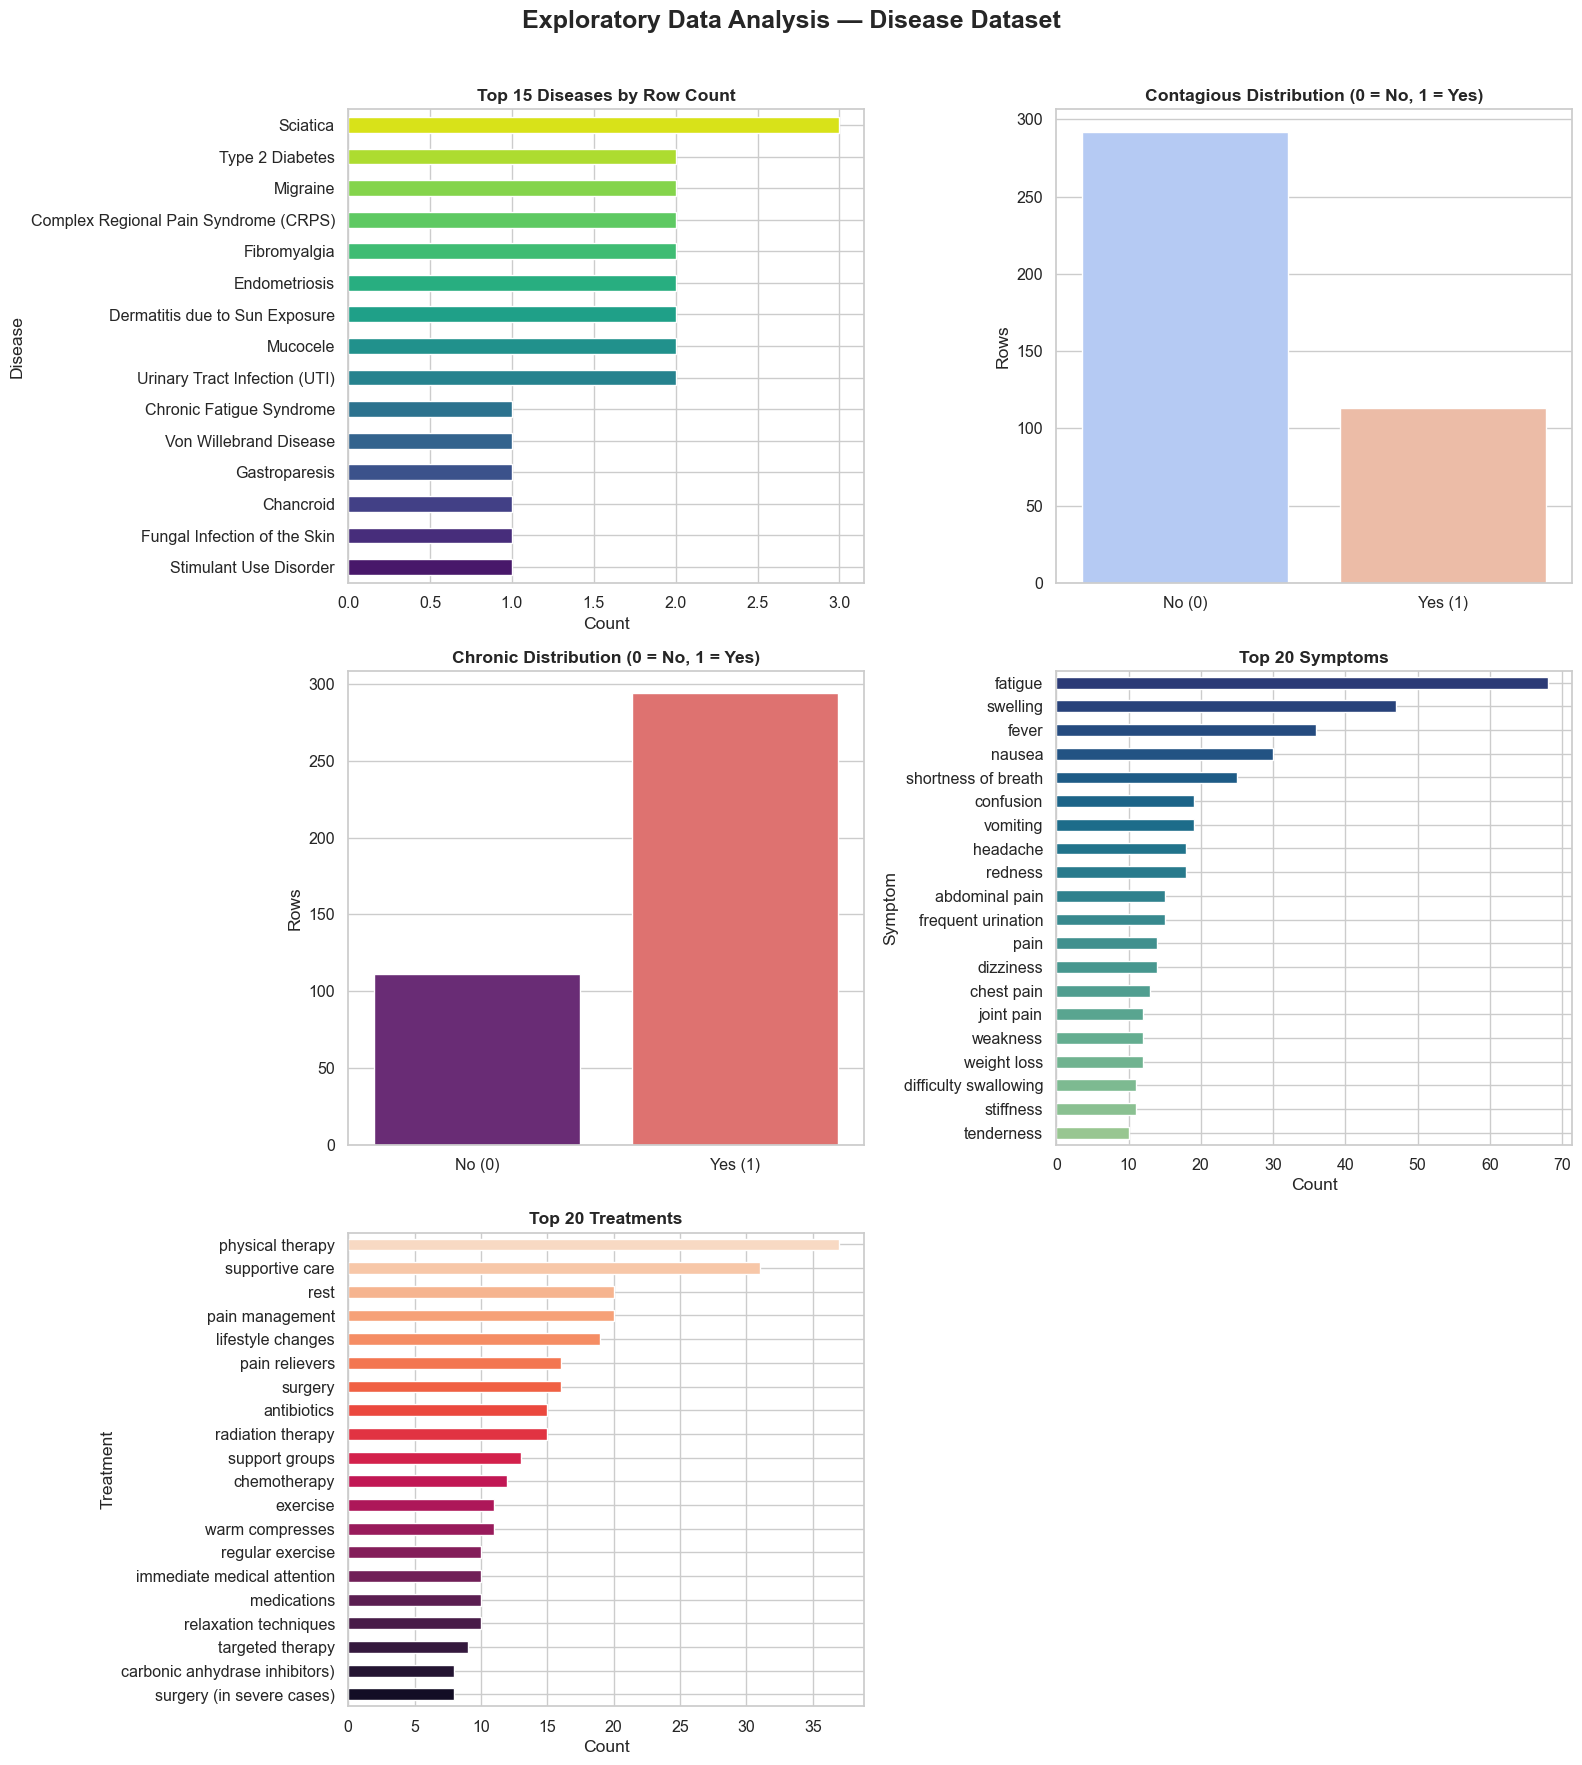

In [11]:
# ============================================================
# COMBINED EDA VISUALIZATIONS
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.05)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle("Exploratory Data Analysis — Disease Dataset", fontsize=18, weight="bold")

# -----------------------------------------
# 1. Top 15 Diseases
# -----------------------------------------
df["Name"].value_counts().head(15).sort_values().plot(
    kind="barh",
    color=sns.color_palette("viridis", 15),
    ax=axes[0,0]
)
axes[0,0].set_title("Top 15 Diseases by Row Count", weight="bold")
axes[0,0].set_xlabel("Count")
axes[0,0].set_ylabel("Disease")

# -----------------------------------------
# 2. Contagious Distribution
# -----------------------------------------
sns.barplot(
    x=df["Contagious"].value_counts().sort_index().index,
    y=df["Contagious"].value_counts().sort_index().values,
    palette="coolwarm",
    ax=axes[0,1]
)
axes[0,1].set_title("Contagious Distribution (0 = No, 1 = Yes)", weight="bold")
axes[0,1].set_xticks([0,1])
axes[0,1].set_xticklabels(["No (0)", "Yes (1)"])
axes[0,1].set_ylabel("Rows")
axes[0,1].set_xlabel("")

# -----------------------------------------
# 3. Chronic Distribution
# -----------------------------------------
sns.barplot(
    x=df["Chronic"].value_counts().sort_index().index,
    y=df["Chronic"].value_counts().sort_index().values,
    palette="magma",
    ax=axes[1,0]
)
axes[1,0].set_title("Chronic Distribution (0 = No, 1 = Yes)", weight="bold")
axes[1,0].set_xticks([0,1])
axes[1,0].set_xticklabels(["No (0)", "Yes (1)"])
axes[1,0].set_ylabel("Rows")
axes[1,0].set_xlabel("")

# -----------------------------------------
# 4. Top 20 Symptoms
# -----------------------------------------
sym_counts.head(20).sort_values().plot(
    kind="barh",
    color=sns.color_palette("crest", 20),
    ax=axes[1,1]
)
axes[1,1].set_title("Top 20 Symptoms", weight="bold")
axes[1,1].set_xlabel("Count")
axes[1,1].set_ylabel("Symptom")

# -----------------------------------------
# 5. Top 20 Treatments
# -----------------------------------------
# Merge last row into one big axis
fig.delaxes(axes[2,1])  # remove empty axis
big_ax = axes[2,0]

treat_counts.head(20).sort_values().plot(
    kind="barh",
    color=sns.color_palette("rocket", 20),
    ax=big_ax
)
big_ax.set_title("Top 20 Treatments", weight="bold")
big_ax.set_xlabel("Count")
big_ax.set_ylabel("Treatment")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [12]:
# ------------ 5) Profiling by label (simple and useful) ------------
# Most common symptoms among contagious=1 vs chronic=1
def top_by_flag(flag_col, list_col, top=15):
    tmp = df.loc[df[flag_col]==1].explode(list_col)[list_col]
    tmp = tmp[tmp.notna() & (tmp != "")]
    return tmp.value_counts().head(top)

print("\n=== Top Symptoms in Contagious=1 ===")
display(top_by_flag("Contagious", "Symptoms_list", 15))

print("\n=== Top Symptoms in Chronic=1 ===")
display(top_by_flag("Chronic", "Symptoms_list", 15))

print("\n=== Top Treatments in Contagious=1 ===")
display(top_by_flag("Contagious", "Treatments_list", 15))

print("\n=== Top Treatments in Chronic=1 ===")
display(top_by_flag("Chronic", "Treatments_list", 15))


=== Top Symptoms in Contagious=1 ===


Symptoms_list
fatigue                  68
fever                    36
shortness of breath      21
nausea                   13
weakness                 10
weight loss              10
headache                 10
cough                     9
swelling                  9
vomiting                  8
loss of appetite          8
pale skin                 8
joint pain                8
sore throat               7
difficulty swallowing     7
Name: count, dtype: int64


=== Top Symptoms in Chronic=1 ===


Symptoms_list
fatigue                56
swelling               30
shortness of breath    23
nausea                 22
fever                  21
confusion              15
headache               13
frequent urination     12
dizziness              11
vomiting               11
chest pain             11
stiffness              11
weight loss            10
joint pain             10
cough                   9
Name: count, dtype: int64


=== Top Treatments in Contagious=1 ===


Treatments_list
supportive care                  18
rest                             10
fluids                            8
antibiotics                       7
pain relievers                    7
exercise                          5
chemotherapy                      5
radiation therapy                 5
targeted therapy                  5
pain management                   5
physical therapy                  4
treatment of underlying cause     4
blood transfusions                4
warm compresses                   3
immunotherapy                     3
Name: count, dtype: int64


=== Top Treatments in Chronic=1 ===


Treatments_list
physical therapy         37
lifestyle changes        19
supportive care          17
surgery                  15
radiation therapy        15
pain management          14
rest                     13
support groups           12
chemotherapy             12
pain relievers           11
exercise                 11
medications              10
targeted therapy          9
relaxation techniques     9
regular exercise          9
Name: count, dtype: int64

In [13]:
# Simple gap view: which symptoms differ most between contagious vs not
sym_in  = df.loc[df["Contagious"]==1].explode("Symptoms_list")["Symptoms_list"].value_counts(normalize=True)
sym_out = df.loc[df["Contagious"]==0].explode("Symptoms_list")["Symptoms_list"].value_counts(normalize=True)
gap = (sym_in - sym_out).abs().dropna().sort_values(ascending=False).head(15)

print("\n=== Symptoms with largest prevalence gap (Contagious vs Not) ===")
display(gap)


=== Symptoms with largest prevalence gap (Contagious vs Not) ===


Symptoms_list
shortness of breath        0.029936
swelling                   0.020893
weight loss                0.014167
weakness                   0.014167
loss of appetite           0.011891
pain                       0.010479
joint pain                 0.009103
headache                   0.008591
difficulty swallowing      0.007500
jaundice                   0.007083
tenderness                 0.006762
redness                    0.006601
rash                       0.005898
limited range of motion    0.005832
wheezing                   0.005481
Name: proportion, dtype: float64

In [14]:
# =========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.decomposition import PCA
import networkx as nx

In [15]:
# ---------------------------
# Aggregate to DISEASE level
# ---------------------------
agg = (
    df.groupby("Name")
      .agg({
          "Disease_Code":"first",
          "Contagious": lambda s: int(s.mean() >= 0.5),
          "Chronic":    lambda s: int(s.mean() >= 0.5),
          "Symptoms_list":   lambda ll: sorted(set(x for L in ll for x in L)),
          "Treatments_list": lambda ll: sorted(set(x for L in ll for x in L))
      })
      .reset_index()
)

# Easy-to-use text for vectorizers
agg["sym_text"] = agg["Symptoms_list"].apply(lambda xs: ", ".join(xs))
agg["trx_text"] = agg["Treatments_list"].apply(lambda xs: ", ".join(xs))
agg["all_text"] = agg["sym_text"] + " || " + agg["trx_text"]

print("Disease-level shape:", agg.shape)
display(agg.head())

Disease-level shape: (395, 9)


,Name,Disease_Code,Contagious,Chronic,Symptoms_list,Treatments_list,sym_text,trx_text,all_text
0,Abdominal Hernia,D087,0,1,"[discomfort or pain, visible bulge or swelling]","[hernia truss, lifestyle changes, surgical rep...","discomfort or pain, visible bulge or swelling","hernia truss, lifestyle changes, surgical repa...","discomfort or pain, visible bulge or swelling ..."
1,Abdominal Injury,D027,0,0,"[abdominal pain, blood in urine or stool, brui...","[ct scan, immediate medical attention, observa...","abdominal pain, blood in urine or stool, bruis...","ct scan, immediate medical attention, observat...","abdominal pain, blood in urine or stool, bruis..."
2,Abscess,D264,1,0,"[fever, pain, pus formation, redness, swelling]","[antibiotics, surgical drainage]","fever, pain, pus formation, redness, swelling","antibiotics, surgical drainage","fever, pain, pus formation, redness, swelling ..."
3,Abscess of Nose,D165,0,0,"[discharge from the nose, pain, redness, swell...","[antibiotics, surgical drainage (in severe cas...","discharge from the nose, pain, redness, swelling","antibiotics, surgical drainage (in severe case...","discharge from the nose, pain, redness, swelli..."
4,Abscess of the Lung,D011,1,0,"[chest pain, cough with phlegm or pus, fatigue...","[antibiotics, drainage or surgical removal of ...","chest pain, cough with phlegm or pus, fatigue,...","antibiotics, drainage or surgical removal of t...","chest pain, cough with phlegm or pus, fatigue,..."


In [16]:
# ---------------------------
# Text features (TF-IDF)
# ---------------------------
vec = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=4000)
X = vec.fit_transform(agg["all_text"])
y_cont = agg["Contagious"].values
y_chro = agg["Chronic"].values


=== SUPERVISED RESULTS ===

Task A: Contagious (0/1) -> Accuracy=0.909  Precision=0.828  Recall=0.857  F1=0.842


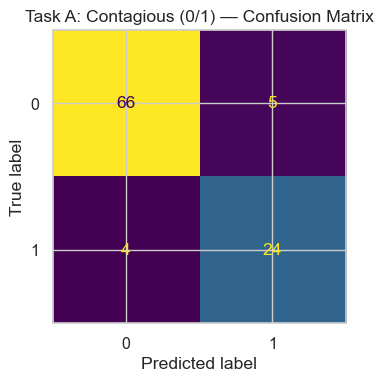

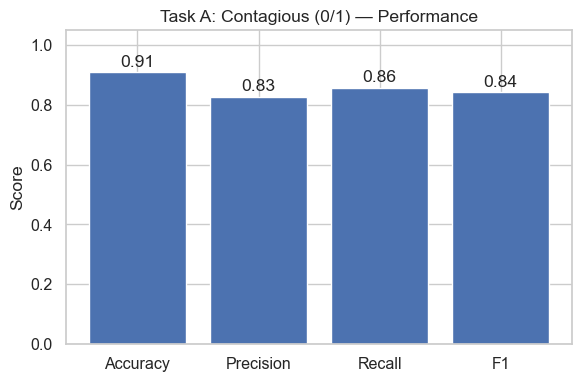


Task B: Chronic (0/1) -> Accuracy=0.828  Precision=0.887  Recall=0.875  F1=0.881


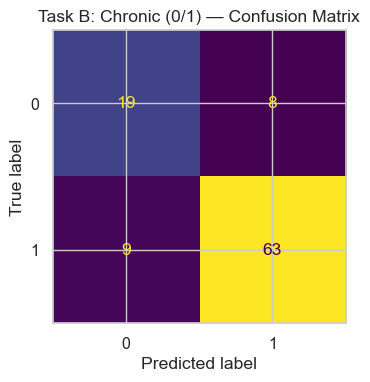

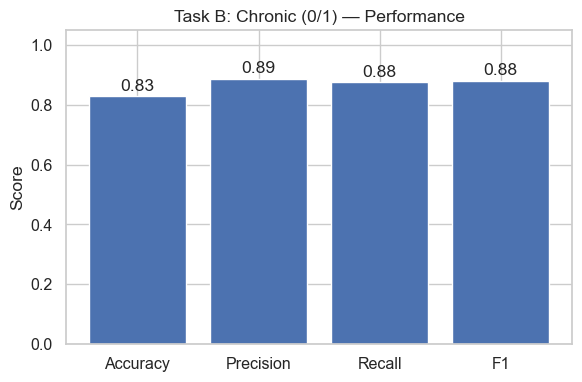

In [17]:
# ---------------------------
# Supervised classification (two tasks) + VISUAL METRICS
# ---------------------------
def run_task(X, y, title):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    clf = LogisticRegression(max_iter=3000, class_weight="balanced")
    clf.fit(Xtr, ytr)
    ypr = clf.predict(Xte)

    acc = accuracy_score(yte, ypr)
    pre = precision_score(yte, ypr, zero_division=0)
    rec = recall_score(yte, ypr, zero_division=0)
    f1  = f1_score(yte, ypr, zero_division=0)
    print(f"\n{title} -> Accuracy={acc:.3f}  Precision={pre:.3f}  Recall={rec:.3f}  F1={f1:.3f}")

    # Confusion Matrix (clear for non-technical readers)
    fig, ax = plt.subplots(figsize=(4.5,4))
    ConfusionMatrixDisplay(confusion_matrix(yte, ypr)).plot(ax=ax, colorbar=False)
    ax.set_title(f"{title} — Confusion Matrix")
    plt.tight_layout(); plt.show()

    # Metrics bar (labels on bars)
    vals = [acc, pre, rec, f1]
    labs = ["Accuracy","Precision","Recall","F1"]
    plt.figure(figsize=(6,4))
    plt.bar(labs, vals)
    for i,v in enumerate(vals): plt.text(i, v+0.02, f"{v:.2f}", ha="center")
    plt.ylim(0, 1.05)
    plt.title(f"{title} — Performance")
    plt.ylabel("Score")
    plt.tight_layout(); plt.show()

    return clf

print("\n=== SUPERVISED RESULTS ===")
clf_cont = run_task(X, y_cont, "Task A: Contagious (0/1)")
clf_chro = run_task(X, y_chro, "Task B: Chronic (0/1)")


=== INTERPRETABLE FEATURES ===


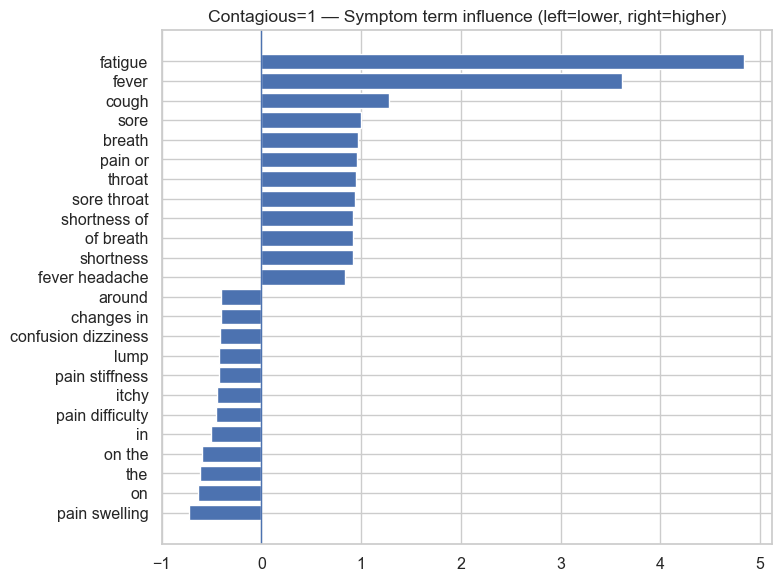

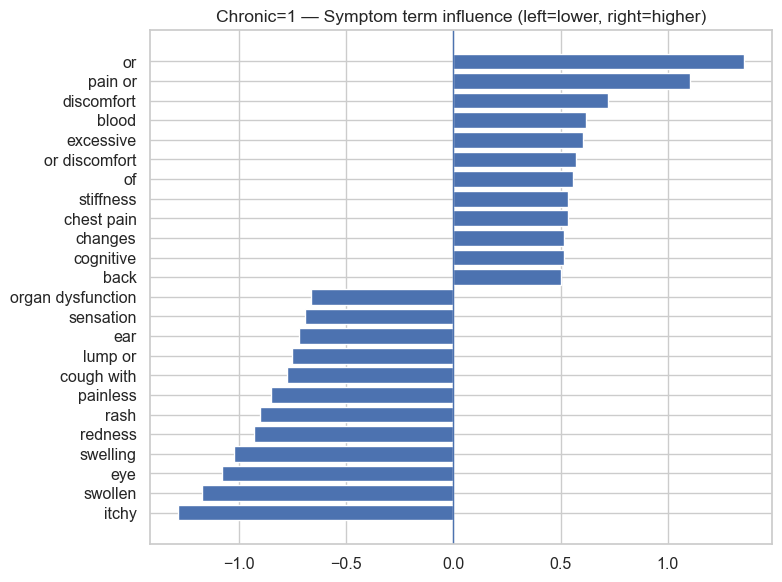

In [18]:
# ---------------------------
# Human-readable symptom drivers (simple explanation)
# ---------------------------
sym_vec = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=3000)
X_sym = sym_vec.fit_transform(agg["sym_text"])

def show_top_terms(X, y, title, k=12):
    lr = LogisticRegression(max_iter=3000, class_weight="balanced")
    lr.fit(X, y)
    vocab = np.array(sym_vec.get_feature_names_out())
    coefs = lr.coef_.ravel()
    idx_pos = np.argsort(coefs)[-k:]
    idx_neg = np.argsort(coefs)[:k]
    idx = np.r_[idx_neg, idx_pos]
    plt.figure(figsize=(8,6))
    plt.barh(vocab[idx], coefs[idx])
    plt.axvline(0, linewidth=1)
    plt.title(title + " — Symptom term influence (left=lower, right=higher)")
    plt.tight_layout(); plt.show()

print("\n=== INTERPRETABLE FEATURES ===")
show_top_terms(X_sym, y_cont, "Contagious=1")
show_top_terms(X_sym, y_chro, "Chronic=1")


Graph: 2632 nodes | 3690 edges


C:\Users\1999m\AppData\Local\Temp\ipykernel_13872\2438559345.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


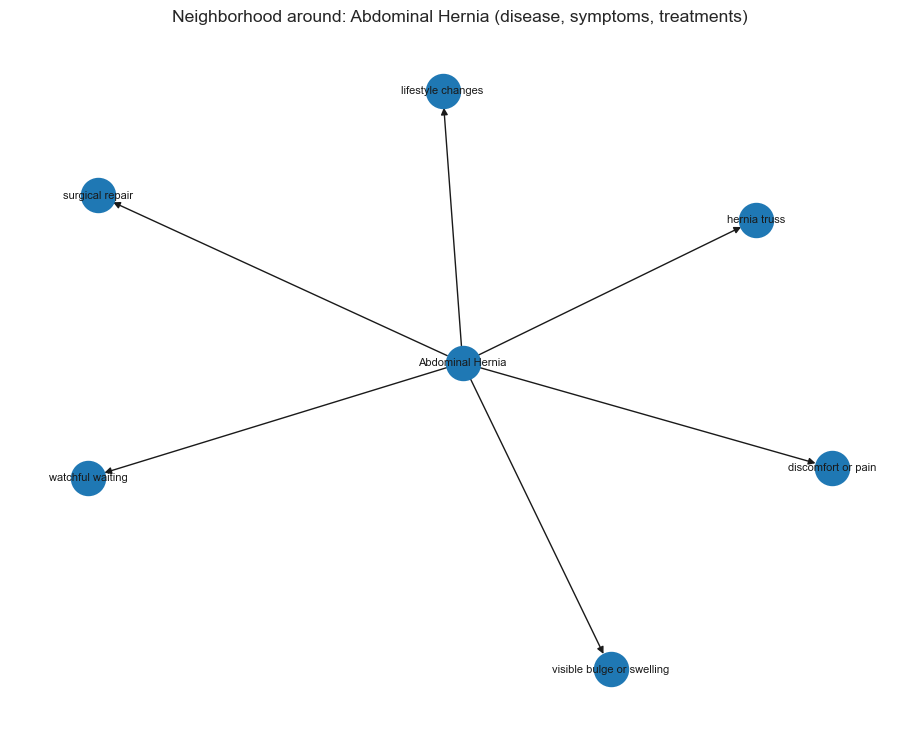

In [19]:
# ---------------------------
# Knowledge Graph (Disease–Symptom–Treatment)
# ---------------------------
G = nx.MultiDiGraph()
for _, r in agg.iterrows():
    dz = r["Name"]
    G.add_node(dz, kind="disease", chronic=int(r["Chronic"]), contagious=int(r["Contagious"]))
    for s in r["Symptoms_list"]:
        if s: G.add_node(s, kind="symptom"); G.add_edge(dz, s, rel="has_symptom")
    for t in r["Treatments_list"]:
        if t: G.add_node(t, kind="treatment"); G.add_edge(dz, t, rel="treated_with")

print("\nGraph:", G.number_of_nodes(), "nodes |", G.number_of_edges(), "edges")

# Visualize one disease neighborhood (easy to read)
top_disease = agg["Name"].value_counts().index[0]
H = nx.ego_graph(G, top_disease, radius=1)
pos = nx.spring_layout(H, seed=42)
plt.figure(figsize=(9,7))
nx.draw(H, pos, with_labels=True, node_size=600, font_size=8)
plt.title(f"Neighborhood around: {top_disease} (disease, symptoms, treatments)")
plt.tight_layout(); plt.show()

Communities: 103 | Modularity: 0.391


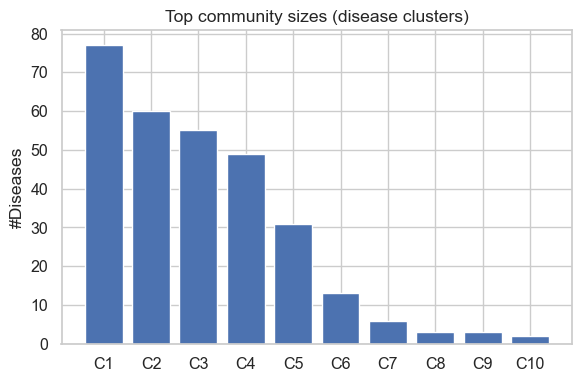

In [20]:
# ---------------------------
# Disease–Disease projection by shared symptoms
# ---------------------------
diseases = [n for n in G.nodes() if G.nodes[n].get("kind")=="disease"]
proj = nx.Graph(); proj.add_nodes_from(diseases)

# Map disease -> symptom set
dz_sym = {d: {nbr for _, nbr, dat in G.out_edges(d, data=True) if dat.get("rel")=="has_symptom"} for d in diseases}
for i,d1 in enumerate(diseases):
    for d2 in diseases[i+1:]:
        w = len(dz_sym[d1] & dz_sym[d2])
        if w > 0:
            proj.add_edge(d1, d2, weight=w)

from networkx.algorithms.community import greedy_modularity_communities, quality
comms = list(greedy_modularity_communities(proj, weight="weight"))
Q = quality.modularity(proj, comms, weight="weight")
print(f"Communities: {len(comms)} | Modularity: {Q:.3f}")

# Bar chart of top community sizes (non-technical summary)
sizes = sorted([len(c) for c in comms], reverse=True)[:10]
plt.figure(figsize=(6,4))
plt.bar([f"C{i+1}" for i in range(len(sizes))], sizes)
plt.title("Top community sizes (disease clusters)")
plt.ylabel("#Diseases")
plt.tight_layout(); plt.show()

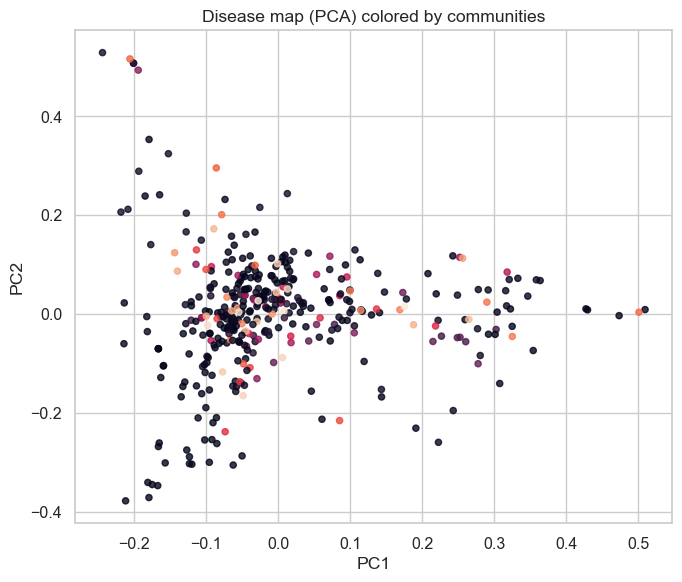


Potential treatment gaps (heuristic — higher suggests review):


,Disease,#Symptoms,#Treatments,GapScore
387,Volvulus,6,1,6.0
155,Glucocorticoid Deficiency,5,1,5.0
62,Choledocholithiasis,9,2,4.5
161,Hashimoto Thyroiditis,7,2,3.5
237,Mucoepidermoid carcinoma,6,2,3.0
19,Amyloidosis,3,1,3.0
353,Syphilis,9,3,3.0
173,Hirschsprung Disease,3,1,3.0
63,Cholesteatoma,5,2,2.5
383,Vitamin A Deficiency,5,2,2.5


In [21]:
# ---------------------------
# 2D view of diseases (PCA) colored by community id
# ---------------------------
# Reuse X (all_text). Align rows:
name_to_comm = {}
for i,c in enumerate(comms):
    for n in c: name_to_comm[n] = i
comm_labels = agg["Name"].map(name_to_comm).fillna(-1).values  # -1 for isolated

# Dense matrix for PCA (safely convert sparse)
Xdense = X.toarray()
Z = PCA(n_components=2, random_state=42).fit_transform(Xdense)

plt.figure(figsize=(7,6))
sc = plt.scatter(Z[:,0], Z[:,1], c=comm_labels, s=20, alpha=0.8)
plt.title("Disease map (PCA) colored by communities")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.show()

# ---------------------------
# 8) Simple “treatment gap” heuristic table (readable)
#    High symptom breadth but few treatments → potential gap
# ---------------------------
rows = []
for _, r in agg.iterrows():
    n_sym = len(r["Symptoms_list"])
    n_trx = len(r["Treatments_list"])
    gap_score = n_sym / max(1, n_trx)
    rows.append([r["Name"], n_sym, n_trx, round(gap_score, 2)])
gaps = pd.DataFrame(rows, columns=["Disease","#Symptoms","#Treatments","GapScore"]).sort_values("GapScore", ascending=False).head(15)

print("\nPotential treatment gaps (heuristic — higher suggests review):")
display(gaps)

In [22]:
# ============================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, sys, subprocess
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

# -------------------------------------------------------
# Small utils: safe import / install and plotting helper
# -------------------------------------------------------
def ensure(pkg_import, pip_name=None):
    """
    Try to import a package; if it fails, try pip install once.
    Returns the imported module or None if still unavailable.
    """
    try:
        return __import__(pkg_import)
    except Exception:
        pip = pip_name or pkg_import
        try:
            print(f"Trying to install: {pip} ...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pip, "-q"])
            return __import__(pkg_import)
        except Exception as e:
            print(f"Could not install {pip}. Proceeding without it. ({e})")
            return None

def show_metric_bar(title, metrics: dict):
    items = ["accuracy","precision","recall","f1"]
    vals = [metrics.get(k, np.nan) for k in items]
    plt.figure(figsize=(6,4))
    plt.bar([i.title() for i in items], vals)
    for i,v in enumerate(vals):
        if not np.isnan(v):
            plt.text(i, v+0.02, f"{v:.2f}", ha="center")
    plt.ylim(0, 1.05); plt.ylabel("Score"); plt.title(title); plt.tight_layout(); plt.show()

np.random.seed(42)

In [23]:
# -------------------------------------------------------
# (Re)build disease-level table if not in memory
# -------------------------------------------------------
if "agg" not in globals():
    # Expect df to exist; if not, you can re-read your CSV here.
    def split_list(x):
        if pd.isna(x): return []
        return [p.strip().lower() for p in str(x).split(",") if p.strip()]
    if "Symptoms_list" not in df.columns: df["Symptoms_list"] = df["Symptoms"].apply(split_list)
    if "Treatments_list" not in df.columns: df["Treatments_list"] = df["Treatments"].apply(split_list)
    agg = (
        df.groupby("Name")
          .agg({
              "Disease_Code":"first",
              "Contagious": lambda s: int(pd.Series(s).astype(int).mean()>=0.5),
              "Chronic":    lambda s: int(pd.Series(s).astype(int).mean()>=0.5),
              "Symptoms_list":   lambda ll: sorted(set(x for L in ll for x in L)),
              "Treatments_list": lambda ll: sorted(set(x for L in ll for x in L))
          })
          .reset_index()
    )
    agg["sym_text"] = agg["Symptoms_list"].apply(lambda xs: ", ".join(xs))
    agg["trx_text"] = agg["Treatments_list"].apply(lambda xs: ", ".join(xs))
    agg["all_text"] = agg["sym_text"] + " || " + agg["trx_text"]

In [24]:
# -------------------------------------------------------
# BIOBERT embeddings (fallback to TF-IDF)
# -------------------------------------------------------
transformers = ensure("transformers")
torch = ensure("torch")
USE_BIOBERT = transformers is not None and torch is not None

if USE_BIOBERT:
    from transformers import AutoTokenizer, AutoModel
    try:
        tok = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
        mdl = AutoModel.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
        mdl.eval()

        def mean_pool(text):
            if not text or str(text).strip()=="":
                return np.zeros(mdl.config.hidden_size, dtype="float32")
            with torch.no_grad():
                inp = tok(str(text), return_tensors="pt", truncation=True, max_length=128)
                out = mdl(**inp).last_hidden_state.mean(1).squeeze().cpu().numpy().astype("float32")
            return out

        print("Encoding disease texts with BioBERT (symptoms+treatments)...")
        emb_sym = np.stack([mean_pool(t) for t in agg["sym_text"]])
        emb_trx = np.stack([mean_pool(t) for t in agg["trx_text"]])
        X_dense_bio = (emb_sym + emb_trx) / 2.0
        BIO_SOURCE = "BioBERT"
    except Exception as e:
        print(f"BioBERT unavailable at runtime ({e}). Falling back to TF-IDF.")
        USE_BIOBERT = False

if not USE_BIOBERT:
    # TF-IDF fallback (same as earlier but rebuilt here for completeness)
    vec_fallback = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=4000)
    X_sparse = vec_fallback.fit_transform(agg["all_text"])
    X_dense_bio = X_sparse.toarray().astype("float32")
    BIO_SOURCE = "TF-IDF (fallback)"

print(f"Vector source: {BIO_SOURCE}; shape: {X_dense_bio.shape}")

BioBERT unavailable at runtime (Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434). Falling back to TF-IDF.
Vector source: TF-IDF (fallback); shape: (395, 2547)


Running Louvain community detection...
Louvain modularity: 0.453


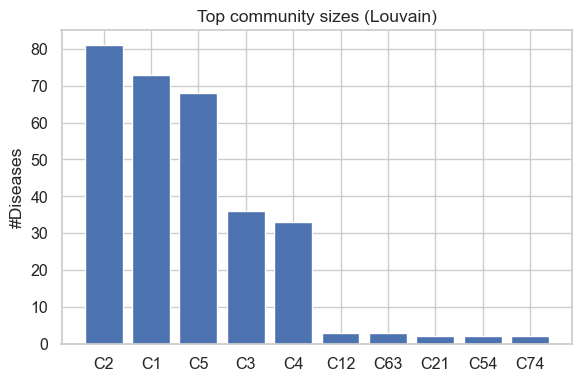

In [25]:
# -------------------------------------------------------
# Louvain communities + modularity on disease–disease projection
# -------------------------------------------------------
# Build disease–disease projection by shared symptoms (if not existing)
import networkx as nx
diseases = agg["Name"].tolist()
proj = nx.Graph(); proj.add_nodes_from(diseases)

dz_sym = {row["Name"]: set(row["Symptoms_list"]) for _, row in agg.iterrows()}
for i, d1 in enumerate(diseases):
    s1 = dz_sym[d1]
    for d2 in diseases[i+1:]:
        w = len(s1 & dz_sym[d2])
        if w > 0:
            proj.add_edge(d1, d2, weight=w)

community = ensure("community", "python-louvain")
if community:
    import community as community_louvain
    print("Running Louvain community detection...")
    partition = community_louvain.best_partition(proj, weight="weight", random_state=42)
    # modularity using python-louvain:
    Q_louvain = community_louvain.modularity(partition, proj, weight="weight")
    print(f"Louvain modularity: {Q_louvain:.3f}")

    # Bar chart of top community sizes
    from collections import Counter
    sizes = Counter(partition.values())
    top_sizes = sizes.most_common(10)
    labs = [f"C{cid}" for cid,_ in top_sizes]
    vals = [cnt for _,cnt in top_sizes]
    plt.figure(figsize=(6,4))
    plt.bar(labs, vals)
    plt.title("Top community sizes (Louvain)")
    plt.ylabel("#Diseases")
    plt.tight_layout(); plt.show()
else:
    print("Louvain not available; keeping earlier greedy modularity results if any.")
    partition, Q_louvain = None, None

In [26]:
# -------------------------------------------------------
# Silhouette score (vector space) using Louvain labels
# -------------------------------------------------------
if partition:
    labels = agg["Name"].map(partition).values
    # Remove singleton clusters (silhouette undefined with 1 label)
    lbls = pd.Series(labels)
    counts = lbls.value_counts()
    keep_mask = lbls.map(counts) > 1
    if keep_mask.sum() > 2 and len(np.unique(lbls[keep_mask])) > 1:
        sil = silhouette_score(X_dense_bio[keep_mask], lbls[keep_mask])
        print(f"Silhouette (Bio/TF-IDF space, Louvain labels, no singletons): {sil:.3f}")
    else:
        print("Silhouette skipped (not enough multi-member clusters).")
else:
    print("Silhouette skipped (no Louvain partition).")

Silhouette (Bio/TF-IDF space, Louvain labels, no singletons): 0.007


CV – RandomForest (Contagious) → {'accuracy': 0.884, 'precision': 0.985, 'recall': 0.595, 'f1': 0.739}


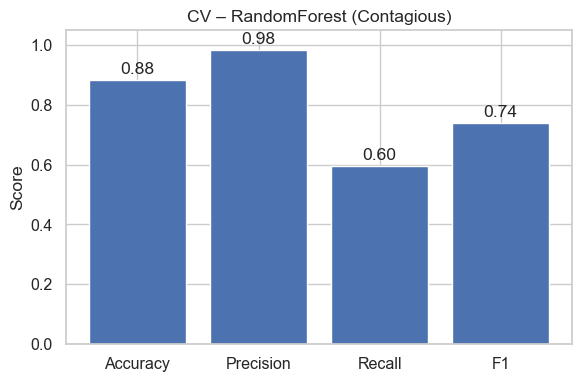

CV – RandomForest (Chronic) → {'accuracy': 0.906, 'precision': 0.901, 'recall': 0.983, 'f1': 0.939}


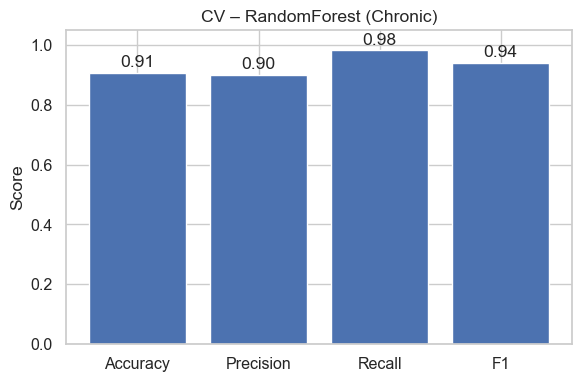

CV – XGBoost (Contagious) → {'accuracy': 0.972, 'precision': 0.99, 'recall': 0.909, 'f1': 0.947}


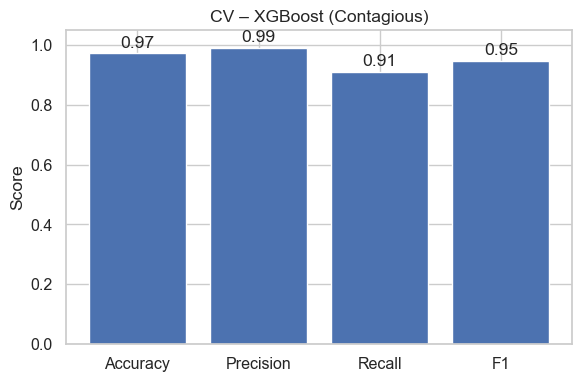

CV – XGBoost (Chronic) → {'accuracy': 0.965, 'precision': 0.983, 'recall': 0.969, 'f1': 0.976}


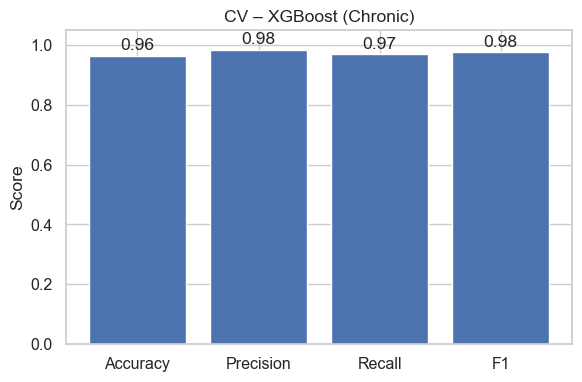

In [27]:
# -------------------------------------------------------
# Additional supervised models + 5-fold CV (RF + XGBoost)
# -------------------------------------------------------
def cv_report_clf(clf, X, y, title):
    cv = StratifiedKFold(5, shuffle=True, random_state=42)
    scores = cross_validate(clf, X, y, cv=cv,
                            scoring=["accuracy","precision","recall","f1"],
                            n_jobs=-1, return_train_score=False)
    metrics = {m: float(scores[f"test_{m}"].mean()) for m in ["accuracy","precision","recall","f1"]}
    print(title, "→", {k: round(v,3) for k,v in metrics.items()})
    show_metric_bar(title, metrics)

y_cont = agg["Contagious"].values
y_chro = agg["Chronic"].values

# RandomForest (tree-based, SHAP-friendly)
rf_cont = RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42, n_jobs=-1)
rf_chro = RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42, n_jobs=-1)
cv_report_clf(rf_cont, X_dense_bio, y_cont, "CV – RandomForest (Contagious)")
cv_report_clf(rf_chro, X_dense_bio, y_chro, "CV – RandomForest (Chronic)")

# XGBoost (optional)
xgb = ensure("xgboost")
if xgb:
    from xgboost import XGBClassifier
    xgb_cont = XGBClassifier(
        n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, random_state=42, n_jobs=-1, objective="binary:logistic", eval_metric="logloss",
        tree_method="hist"
    )
    xgb_chro = XGBClassifier(
        n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, random_state=42, n_jobs=-1, objective="binary:logistic", eval_metric="logloss",
        tree_method="hist"
    )
    cv_report_clf(xgb_cont, X_dense_bio, y_cont, "CV – XGBoost (Contagious)")
    cv_report_clf(xgb_chro, X_dense_bio, y_chro, "CV – XGBoost (Chronic)")
else:
    print("XGBoost not available; skipping XGBoost CV.")


=== SHAP Summary Plot — Contagious ===


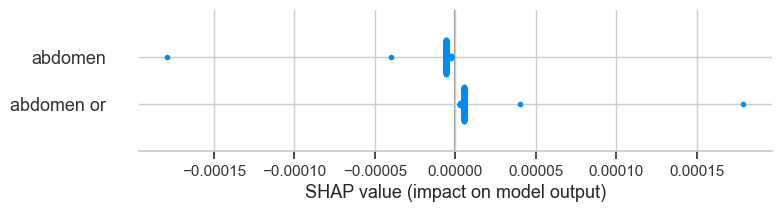


=== SHAP Summary Plot — Chronic ===


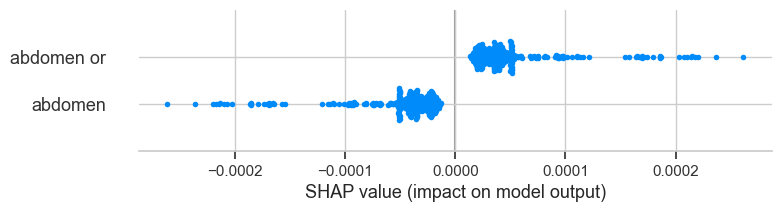


=== SHAP Bar Plot — Contagious ===


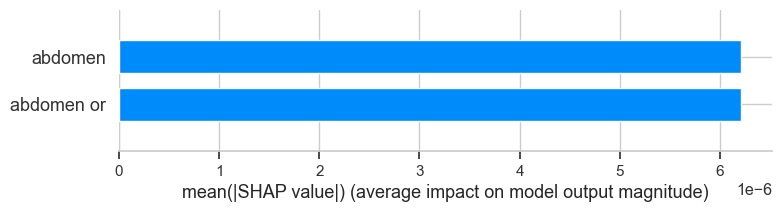


=== SHAP Bar Plot — Chronic ===


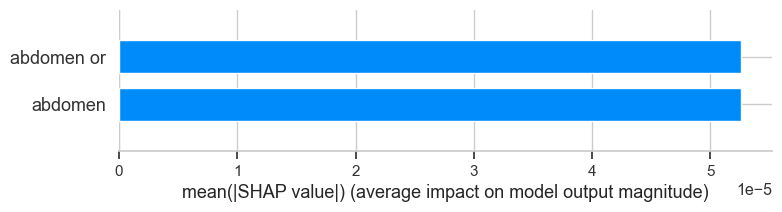

In [28]:
# -------------------------------------------------------
# SHAP explanations for tree models (robust, actual plots)
# -------------------------------------------------------
shap = ensure("shap")
if shap:
    import shap as _shap

    # Fit RF on full disease vectors (BioBERT or TF-IDF fallback)
    rf_cont_fit = RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ).fit(X_dense_bio, y_cont)

    rf_chro_fit = RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ).fit(X_dense_bio, y_chro)

    # Small sample for speed
    rng = np.random.RandomState(42)
    samp_idx = rng.choice(len(agg), size=min(300, len(agg)), replace=False)
    X_sample = X_dense_bio[samp_idx]

    # -------------------------------
    # Robust SHAP value extraction
    # -------------------------------
    def get_shap_values(model, X):
        """
        Return 2D SHAP array (n_samples, n_features) and explainer,
        handling different SHAP versions.
        """
        try:
            expl = _shap.TreeExplainer(model)
            sv = expl.shap_values(X)
        except Exception:
            expl = _shap.Explainer(model, X)
            sv = expl(X).values

        # Handle: list of arrays, 3D arrays, etc.
        if isinstance(sv, list):
            arr = sv[1] if len(sv) > 1 else sv[0]
        else:
            arr = sv
            if arr.ndim == 3:
                # (n_samples, n_classes, n_features) → take pos class if binary
                cls_axis = 1
                pos_idx = 1 if arr.shape[cls_axis] > 1 else 0
                arr = arr[:, pos_idx, :]

        if arr.ndim == 1:
            arr = arr.reshape(-1, 1)

        return np.asarray(arr), expl

    shap_cont, expl_cont = get_shap_values(rf_cont_fit, X_sample)
    shap_chro, expl_chro = get_shap_values(rf_chro_fit, X_sample)

    # -------------------------------
    # Feature names
    # -------------------------------
    if 'vec_fallback' in globals() and not USE_BIOBERT:
        feature_names = np.array(vec_fallback.get_feature_names_out())
    else:
        # BioBERT (or any dense embedding): use generic f0..fN labels
        feature_names = np.array([f"f{i}" for i in range(shap_cont.shape[1])])

    # -------------------------------
    # SHAP SUMMARY PLOTS (no features matrix)
    # -------------------------------
    print("\n=== SHAP Summary Plot — Contagious ===")
    _shap.summary_plot(
        shap_cont,
        feature_names=feature_names,
        show=True
    )

    print("\n=== SHAP Summary Plot — Chronic ===")
    _shap.summary_plot(
        shap_chro,
        feature_names=feature_names,
        show=True
    )

    # -------------------------------
    # SHAP BAR PLOTS (global importance)
    # -------------------------------
    print("\n=== SHAP Bar Plot — Contagious ===")
    _shap.summary_plot(
        shap_cont,
        feature_names=feature_names,
        plot_type="bar",
        show=True
    )

    print("\n=== SHAP Bar Plot — Chronic ===")
    _shap.summary_plot(
        shap_chro,
        feature_names=feature_names,
        plot_type="bar",
        show=True
    )

else:
    print("SHAP not available; skipping SHAP plots.")


# Biomedical NER + GNN + GNNExplainer

In [30]:
import sys, subprocess, importlib, os, math
import numpy as np, pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import networkx as nx

In [31]:
import spacy
nlp = spacy.load("en_core_sci_sm")

In [32]:
model_pkg_url = ("https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/"
                 "releases/v0.5.4/en_core_sci_sm-0.5.4.tar.gz")

try:
    import spacy, scispacy  # noqa
    nlp = spacy.load("en_core_sci_sm")
    print("Loaded spaCy model: en_core_sci_sm")
except Exception as e:
    print(f"Model not available yet ({e}). Installing SciSpaCy + model…")
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "spacy==3.7.2", "scispacy==0.5.4"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", model_pkg_url])
    import spacy as _spacy
    nlp = _spacy.load("en_core_sci_sm")
    print("Loaded spaCy model: en_core_sci_sm")


Loaded spaCy model: en_core_sci_sm


In [33]:
# -------------------------
# small helper to install-import
# -------------------------
def try_import(pkg, pip_name=None, import_name=None):
    name = import_name or pkg
    try:
        return importlib.import_module(name)
    except Exception:
        pip_pkg = pip_name or pkg
        try:
            print(f"Installing {pip_pkg} ...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pip_pkg, "-q"])
            return importlib.import_module(name)
        except Exception as e:
            print(f"Could not import/install {pkg} ({e}).")
            return None

In [34]:
# -------------------------
# 1) Biomedical NER preprocessing using SciSpacy
# -------------------------
print("\n=== 1) Biomedical NER preprocessing (SciSpacy) ===")
spacy = try_import("spacy")
scispacy = try_import("scispacy")
nlp = None
if spacy is None or scispacy is None:
    print("SciSpacy / spaCy not available. Falling back to simple normalization (lowercase + dedupe).")
else:
    # try to load an scispacy model
    model_name = "en_core_sci_sm"
    try:
        nlp = spacy.load(model_name)
        print(f"Loaded spaCy model: {model_name}")
    except Exception:
        # try to download
        try:
            print(f"Installing {model_name} ...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", model_name, "-q"])
            nlp = spacy.load(model_name)
            print(f"Loaded spaCy model: {model_name}")
        except Exception as e:
            print(f"Failed to load {model_name} ({e}). Attempting to install scispacy UMLS linker is skipped.")
            nlp = None

# Define canonicalizer using scispacy NER if available; else fallback simple normalizer
import re
def simple_tokenize_and_norm(text):
    # split on commas/semicolons or parentheses, remove punctuation, lowercase, strip
    if not text or str(text).strip()=="":
        return []
    toks = re.split(r"[;,()\/]+", str(text))
    toks = [re.sub(r"[^a-z0-9\s\-]", "", t.lower()).strip() for t in toks]
    toks = [t for t in toks if t]
    # further canonical: remove extra spaces, unify plurals naive
    toks = [re.sub(r"\s+", " ", t) for t in toks]
    toks = [re.sub(r"\b(s)$", "", t) if len(t.split())==1 and t.endswith("s") else t for t in toks]
    return sorted(set(toks))

def scispacy_extract(text):
    ents = []
    if nlp is None:
        return simple_tokenize_and_norm(text)
    doc = nlp(str(text))
    # take entity spans (text) and normalize whitespace/lowercase
    for ent in doc.ents:
        e = re.sub(r"[^a-z0-9\s\-]", "", ent.text.lower()).strip()
        if e: ents.append(e)
    if not ents:
        # fallback to simple split
        return simple_tokenize_and_norm(text)
    return sorted(set(ents))

# Run canonicalization and replace agg columns
if 'agg' not in globals():
    raise RuntimeError("The disease-level table `agg` is required. Run previous cells first.")

agg = agg.copy()  # work on a copy
agg["sym_canon"] = agg["sym_text"].apply(scispacy_extract)
agg["trx_canon"] = agg["trx_text"].apply(scispacy_extract)

print("Sample canonical symptoms/treatments:")
display(agg[["Name","sym_text","sym_canon","trx_canon"]].head(4))


=== 1) Biomedical NER preprocessing (SciSpacy) ===
Loaded spaCy model: en_core_sci_sm
Sample canonical symptoms/treatments:


,Name,sym_text,sym_canon,trx_canon
0,Abdominal Hernia,"discomfort or pain, visible bulge or swelling","[discomfort, pain, swelling, visible bulge]","[hernia, lifestyle changes, surgical repair, w..."
1,Abdominal Injury,"abdominal pain, blood in urine or stool, bruis...","[abdominal pain, blood, bowel movements, bruis...","[internal bleeding, medical attention, observa..."
2,Abscess,"fever, pain, pus formation, redness, swelling","[fever, pain, pus formation, redness, swelling]","[antibiotics, surgical drainage]"
3,Abscess of Nose,"discharge from the nose, pain, redness, swelling","[discharge, nose, pain, redness, swelling]","[antibiotics, cases, severe, surgical drainage..."


In [35]:
# -------------------------
# 2) Build heterogeneous graph with canonical tokens
#    and compute BioBERT embeddings for symptom/treatment nodes where possible
# -------------------------
print("\n=== 2) Build heterogeneous KG and node embeddings for GNN ===")
G = nx.Graph()
# add disease nodes
for i, row in agg.iterrows():
    node_id = f"D|{i}"    # disease node
    G.add_node(node_id, kind="disease", name=row["Name"], chronic=int(row["Chronic"]), contagious=int(row["Contagious"]))

# add symptom and treatment nodes and edges
sym_map = {}  # canonical token -> node_id
trx_map = {}
for i, row in agg.iterrows():
    dnode = f"D|{i}"
    for s in row["sym_canon"]:
        nid = sym_map.get(s)
        if nid is None:
            nid = f"S|{len(sym_map)}"
            sym_map[s] = nid
            G.add_node(nid, kind="symptom", text=s)
        G.add_edge(dnode, nid, rel="has_symptom")
    for t in row["trx_canon"]:
        nid = trx_map.get(t)
        if nid is None:
            nid = f"T|{len(trx_map)}"
            trx_map[t] = nid
            G.add_node(nid, kind="treatment", text=t)
        G.add_edge(dnode, nid, rel="treated_with")

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())
print("Disease nodes:", len([n for n,d in G.nodes(data=True) if d.get("kind")=="disease"]))
print("Symptom nodes:", len(sym_map), "Treatment nodes:", len(trx_map))


=== 2) Build heterogeneous KG and node embeddings for GNN ===
Nodes: 2740 Edges: 5923
Disease nodes: 395
Symptom nodes: 991 Treatment nodes: 1354


In [36]:
# -------------------------
# 3) Node features: for disease nodes use existing X_dense_bio if available.
#    For symptom/treatment nodes try to embed their text via BioBERT; fallback to averaged char feature.
# -------------------------
print("\n=== 3) Node features: BioBERT embeddings for entities (if available) ===")
# try to use existing X_dense_bio for disease nodes: it aligns to agg order
disease_nodes = [f"D|{i}" for i in range(len(agg))]
feature_dim = None
node_features = {}

# If X_dense_bio exists and matches agg length, use it:
if 'X_dense_bio' in globals() and len(X_dense_bio) == len(agg):
    for i, dnode in enumerate(disease_nodes):
        node_features[dnode] = X_dense_bio[i]
    feature_dim = X_dense_bio.shape[1]
    print("Using existing disease vectors for disease nodes. Dim:", feature_dim)
else:
    print("No disease vectors found or length mismatch; using simple bag-of-words fallback for disease nodes.")
    # fallback: TF-IDF on all_text if available
    if 'vec_fallback' in globals():
        vec = vec_fallback
        Xall = vec.transform(agg["all_text"]).toarray()
        for i,dnode in enumerate(disease_nodes):
            node_features[dnode] = Xall[i]
        feature_dim = Xall.shape[1]
        print("Used TF-IDF fallback. Dim:", feature_dim)
    else:
        # last resort: small random features
        feature_dim = 64
        for i,dnode in enumerate(disease_nodes):
            node_features[dnode] = np.random.RandomState(42).randn(feature_dim).astype("float32")
        print("Used random features. Dim:", feature_dim)

# Attempt BioBERT for symptom/treatment nodes (if transformers available)
transformers = try_import("transformers")
torch = try_import("torch")
use_biobert = False
if transformers and torch:
    try:
        from transformers import AutoTokenizer, AutoModel
        tok = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
        mdl = AutoModel.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
        mdl.eval()
        use_biobert = True
        print("BioBERT loaded for symptom/treatment embedding.")
    except Exception as e:
        print("BioBERT load failed:", e)
        use_biobert = False

def biobert_embed(text):
    if not use_biobert or not text:
        return None
    with torch.no_grad():
        inp = tok(str(text), return_tensors="pt", truncation=True, max_length=128)
        out = mdl(**inp).last_hidden_state.mean(1).squeeze().cpu().numpy().astype("float32")
    return out

# embed symptom nodes
for s, nid in sym_map.items():
    v = biobert_embed(s)
    if v is None:
        # simple fallback: character-level normalized vector
        arr = np.zeros(feature_dim, dtype="float32")
        txt = s or ""
        # hash characters to get deterministic pseudo-vector
        r = np.frombuffer((txt*3).encode("utf-8"), dtype=np.uint8)
        arr[:min(len(r), feature_dim)] = (r[:min(len(r), feature_dim)] / 255.0)
        node_features[nid] = arr
    else:
        # if biobert dim differs from disease dim, reduce/expand via simple projection
        if v.shape[0] != feature_dim:
            # project/truncate or pad
            if v.shape[0] > feature_dim:
                v = v[:feature_dim]
            else:
                v = np.pad(v, (0, feature_dim - v.shape[0]), mode='constant')
        node_features[nid] = v

# embed treatment nodes
for t, nid in trx_map.items():
    v = biobert_embed(t)
    if v is None:
        arr = np.zeros(feature_dim, dtype="float32")
        txt = t or ""
        r = np.frombuffer((txt*3).encode("utf-8"), dtype=np.uint8)
        arr[:min(len(r), feature_dim)] = (r[:min(len(r), feature_dim)] / 255.0)
        node_features[nid] = arr
    else:
        if v.shape[0] != feature_dim:
            if v.shape[0] > feature_dim:
                v = v[:feature_dim]
            else:
                v = np.pad(v, (0, feature_dim - v.shape[0]), mode='constant')
        node_features[nid] = v

print("Built node features for all node types. Example dims:", feature_dim)


=== 3) Node features: BioBERT embeddings for entities (if available) ===
Using existing disease vectors for disease nodes. Dim: 2547
BioBERT load failed: Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434
Built node features for all node types. Example dims: 2547



=== 4) GNN training + GNNExplainer ===
Epoch 20/80 loss: 0.2764
Epoch 40/80 loss: 0.1237
Epoch 60/80 loss: 0.0868
Epoch 80/80 loss: 0.0675

GNN test (predict Chronic) -> Acc=0.838, Prec=0.855, Rec=0.947, F1=0.899


C:\Users\1999m\anaconda3\envs\torch311\Lib\site-packages\torch_geometric\deprecation.py:12: UserWarning: 'nn.models.GNNExplainer' is deprecated, use 'explain.Explainer' with 'explain.algorithm.GNNExplainer' instead
  warnings.warn(out)


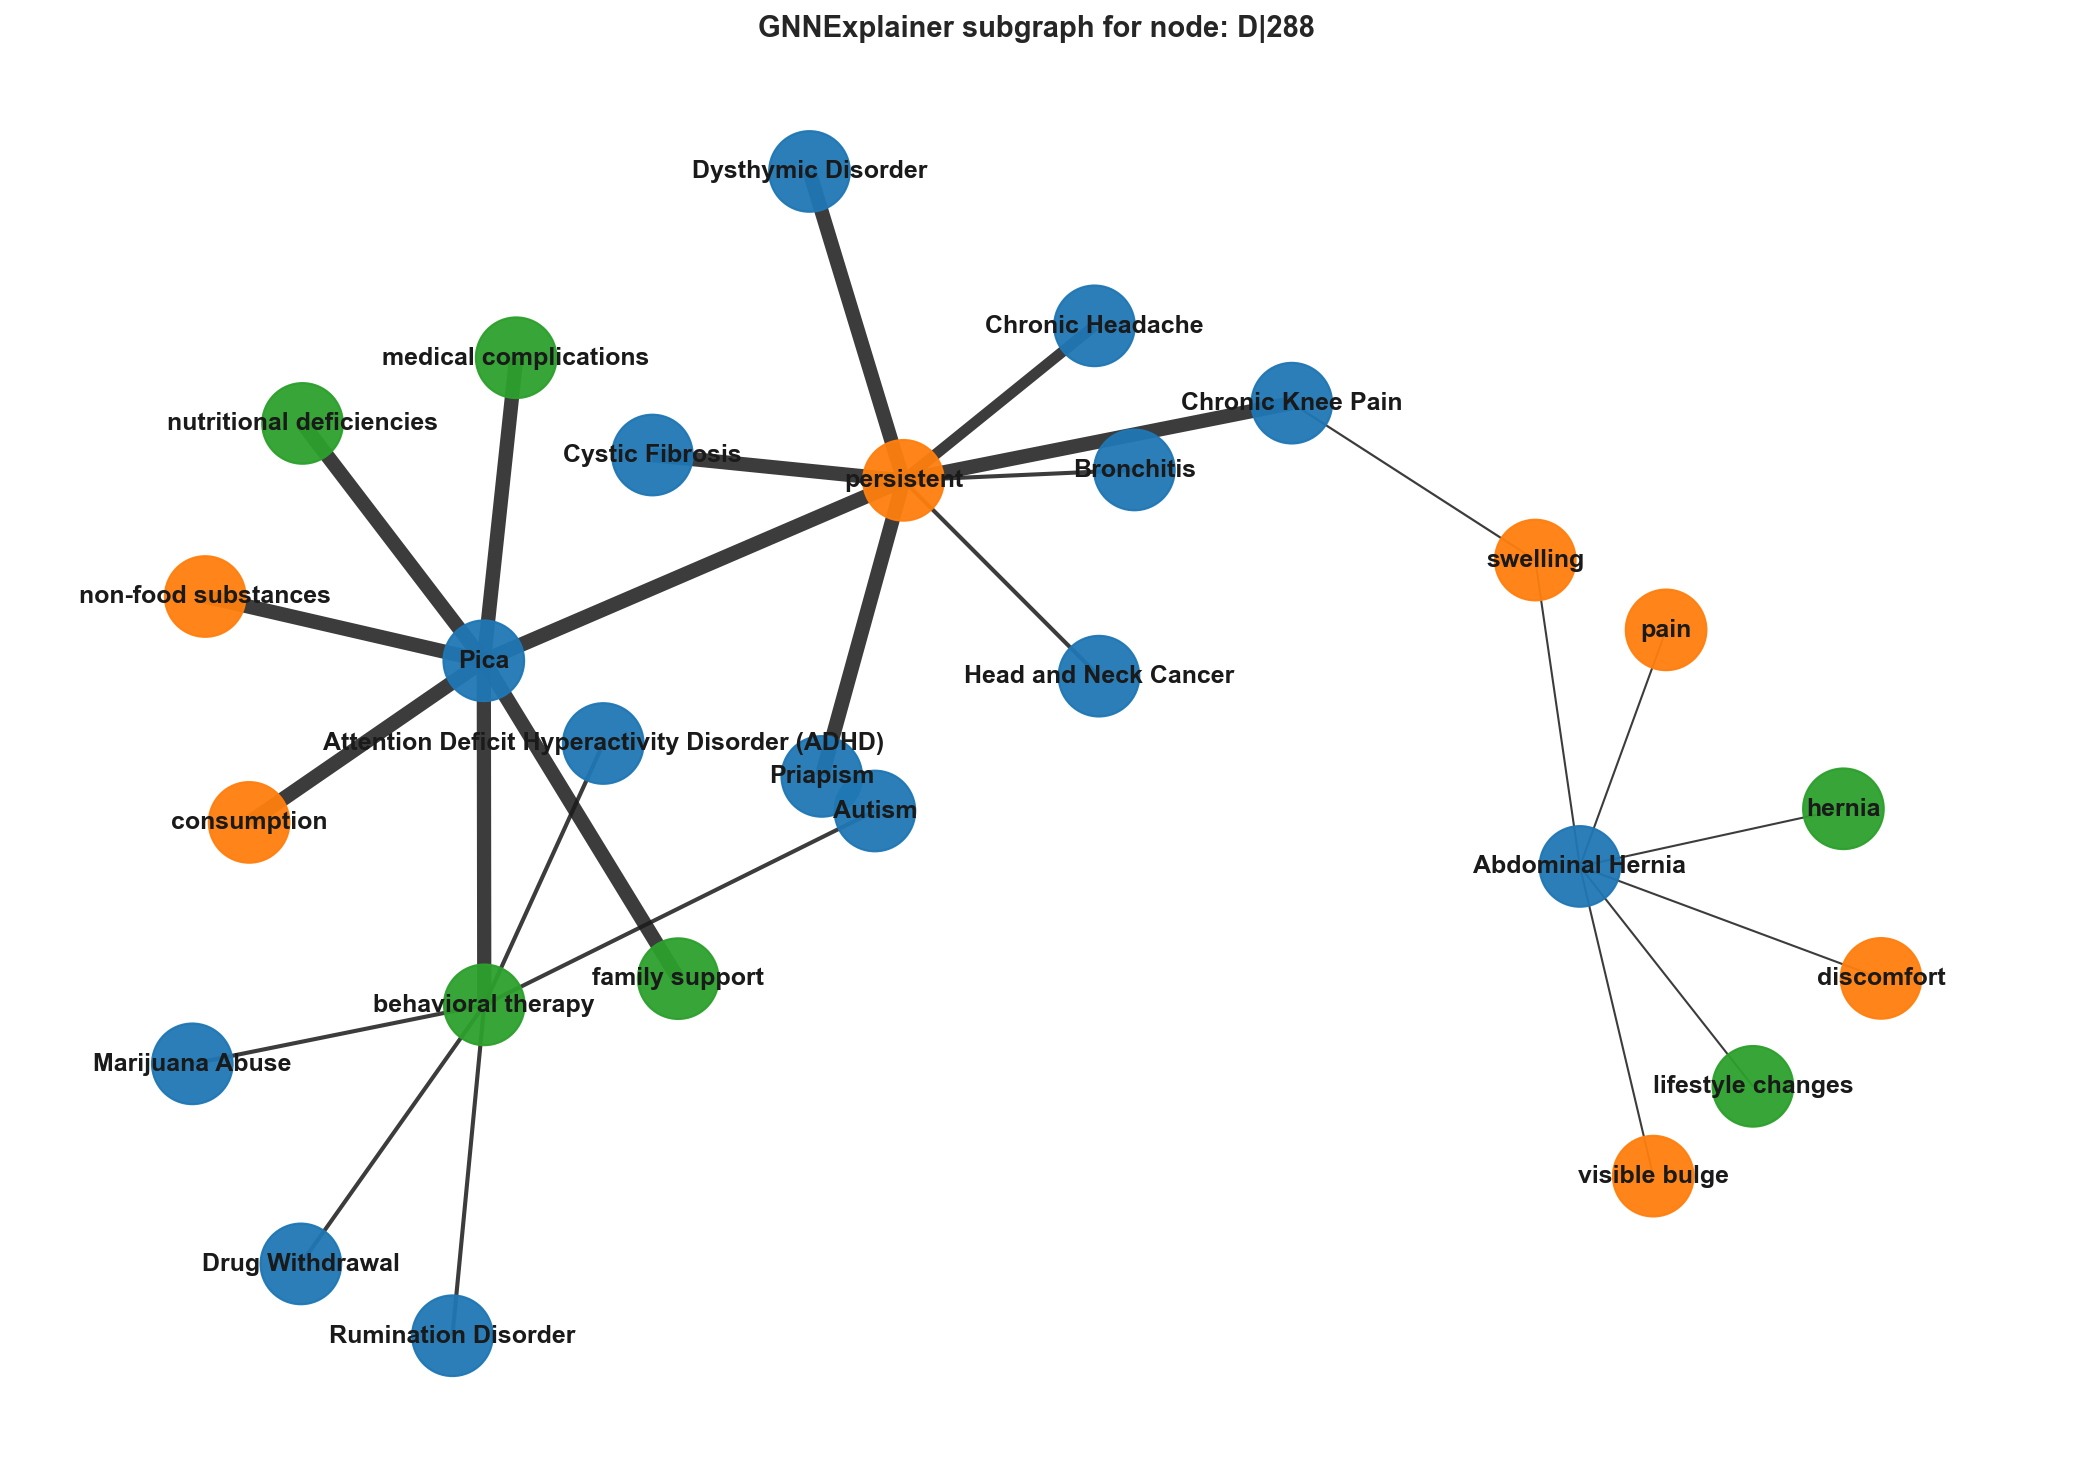

In [71]:
# -------------------------
# 4) Convert to PyG Data and train a small GCN on disease nodes
# -------------------------
print("\n=== 4) GNN training + GNNExplainer ===")

import numpy as np
import torch
import networkx as nx
import matplotlib.pyplot as plt

try:
    from torch_geometric.data import Data
    from torch_geometric.nn import GCNConv, GNNExplainer
except ImportError:
    # -------------------------
    # Fallback: no PyG -> simple surrogate explanation with NetworkX
    # -------------------------
    print("PyTorch Geometric not available. Skipping GNN training. Showing NetworkX surrogate explanation instead.")

    # Simple surrogate explanation: for a selected disease, rank neighbor symptoms/treatments by degree
    sample_d = agg["Name"].iloc[0]
    dnode = f"D|{0}"
    neighbors = list(G.neighbors(dnode))
    ranked = sorted(neighbors, key=lambda n: G.degree(n), reverse=True)

    print(f"\nSurrogate explanation for disease '{sample_d}': "
          f"top connected symptoms/treatments (by prevalence)")
    for n in ranked[:15]:
        nd = G.nodes[n]
        print("-", nd.get("text") or nd.get("name"),
              "| kind:", nd.get("kind"),
              "| degree:", G.degree(n))

else:
    # -------------------------
    # Build PyG graph from NetworkX graph
    # -------------------------
    all_nodes = list(G.nodes())
    node2idx = {n: i for i, n in enumerate(all_nodes)}
    N = len(all_nodes)

    # feature matrix
    X = np.vstack([node_features[n] for n in all_nodes]).astype("float32")

    # edge_index (undirected)
    edge_index = [[], []]
    for u, v in G.edges():
        edge_index[0].append(node2idx[u])
        edge_index[1].append(node2idx[v])
        edge_index[0].append(node2idx[v])
        edge_index[1].append(node2idx[u])
    edge_index = torch.tensor(edge_index, dtype=torch.long)

    x_t = torch.tensor(X, dtype=torch.float)

    # labels: only for disease nodes -> predict 'Chronic'
    labels = np.full((N,), -1, dtype=np.int64)
    for i, row in agg.iterrows():
        dn = f"D|{i}"
        labels[node2idx[dn]] = int(row["Chronic"])
    y = torch.tensor(labels, dtype=torch.long)

    data = Data(x=x_t, edge_index=edge_index, y=y)

    # -------------------------
    # Train/test masks (only disease nodes)
    # -------------------------
    disease_idx = [node2idx[f"D|{i}"] for i in range(len(agg))]

    rng = np.random.RandomState(42)
    perm = rng.permutation(len(disease_idx))
    train_n = int(0.75 * len(disease_idx))
    train_idx = [disease_idx[i] for i in perm[:train_n]]
    test_idx = [disease_idx[i] for i in perm[train_n:]]

    train_mask = torch.zeros(N, dtype=torch.bool)
    test_mask = torch.zeros(N, dtype=torch.bool)
    train_mask[train_idx] = True
    test_mask[test_idx] = True

    data.train_mask = train_mask
    data.test_mask = test_mask

    # -------------------------
    # Define small GCN
    # -------------------------
    class SmallGCN(torch.nn.Module):
        def __init__(self, in_channels, hidden=64, out_channels=2):
            super().__init__()
            self.conv1 = GCNConv(in_channels, hidden)
            self.conv2 = GCNConv(hidden, out_channels)
            self.act = torch.nn.ReLU()

        def forward(self, x, edge_index):
            h = self.act(self.conv1(x, edge_index))
            h = self.conv2(h, edge_index)
            return h

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SmallGCN(feature_dim, hidden=64, out_channels=2).to(device)
    data = data.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    loss_fn = torch.nn.CrossEntropyLoss()

    # -------------------------
    # Train GCN
    # -------------------------
    model.train()
    epochs = 80
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = loss_fn(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()
        if epoch % 20 == 0:
            print(f"Epoch {epoch}/{epochs} loss: {loss.item():.4f}")

    # -------------------------
    # Evaluate on test disease nodes
    # -------------------------
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        pred = logits.argmax(dim=1).cpu().numpy()

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    y_true = data.y.cpu().numpy()
    mask = data.test_mask.cpu().numpy()

    acc = accuracy_score(y_true[mask], pred[mask])
    pre = precision_score(y_true[mask], pred[mask], zero_division=0)
    rec = recall_score(y_true[mask], pred[mask], zero_division=0)
    f1 = f1_score(y_true[mask], pred[mask], zero_division=0)

    print(f"\nGNN test (predict Chronic) -> "
          f"Acc={acc:.3f}, Prec={pre:.3f}, Rec={rec:.3f}, F1={f1:.3f}")

    # -------------------------
    # GNNExplainer: explain a single disease node (choose one from test)
    # -------------------------
    try:
        explainer = GNNExplainer(model, epochs=200, return_type='log_prob')

        # choose a test disease node to explain
        node_to_explain = test_idx[0]
        node_to_explain = torch.tensor(node_to_explain, dtype=torch.long).to(device)

        model.eval()
        node_feat_mask, edge_mask = explainer.explain_node(
            node_to_explain.item(), data.x, data.edge_index
        )

        # Get top-k edges by importance
        edge_mask = edge_mask.cpu().detach().numpy()
        edge_index_np = data.edge_index.cpu().numpy()
        edges = list(zip(edge_index_np[0], edge_index_np[1], edge_mask))

        top_k = min(50, len(edges))
        edges_sorted = sorted(edges, key=lambda x: x[2], reverse=True)[:top_k]

        important_nodes = set()
        for u, v, w in edges_sorted:
            important_nodes.add(u)
            important_nodes.add(v)

        # map back to original node ids
        imp_nodes = [all_nodes[n] for n in important_nodes]
        subG = G.subgraph(imp_nodes).copy()

        # importance weights dict (for edge widths)
        edge_weights = {}
        for u, v, w in edges_sorted:
            nu, nv = all_nodes[u], all_nodes[v]
            edge_weights[(nu, nv)] = w

        # ---------- improved visualization ----------
        plt.figure(figsize=(14, 10), dpi=150)

        pos = nx.spring_layout(subG, seed=42, k=0.5)

        node_colors = []
        labels = {}
        for n in subG.nodes():
            kind = G.nodes[n].get("kind")
            if kind == "disease":
                node_colors.append("tab:blue")
            elif kind == "symptom":
                node_colors.append("tab:orange")
            else:
                node_colors.append("tab:green")

            labels[n] = G.nodes[n].get("text") or G.nodes[n].get("name")

        # big bubbles
        nx.draw_networkx_nodes(
            subG, pos,
            node_color=node_colors,
            node_size=1500,
            alpha=0.95,
        )

        # edge widths scaled by importance
        edge_list = list(subG.edges())
        weights = [edge_weights.get((u, v), edge_weights.get((v, u), 0.01))
                   for u, v in edge_list]
        maxw = max(weights) if weights else 1.0
        widths = [1 + 6 * (w / maxw) for w in weights]

        nx.draw_networkx_edges(
            subG, pos,
            width=widths,
            alpha=0.85,
        )

        # clearer labels
        nx.draw_networkx_labels(
            subG, pos,
            labels=labels,
            font_size=12,
            font_weight="bold",
        )

        plt.title(
            f"GNNExplainer subgraph for node: "
            f"{all_nodes[node_to_explain.cpu().item()]}",
            fontsize=14,
            fontweight="bold",
        )
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print("GNNExplainer failed or not available:", e)
        print("If PyG version mismatched, consider upgrading/downgrading "
              "torch_geometric to match torch.")
